# 1. Data Loading and Dataset Overview

This part shows the gas monitoring dataset from the SQLite database and performs initial inspection of the dataset structure, feature types, and dataset dimensions.

In [55]:
#Import libraries for database connection and data analysis
import sqlite3
import pandas as pd

In [56]:
#Connect to the SQLite database
conn = sqlite3.connect("gas_monitoring.db")

In [8]:
#Retrieve all table names from the SQLite database
query = """ SELECT name FROM sqlite_master WHERE type='table'; """

#Execute SQL query and display available tables
tables = pd.read_sql(query, conn)

tables

,name
0,gas_monitoring


In [9]:
#Load all records from the gas_monitoring table
df = pd.read_sql("SELECT * FROM gas_monitoring", conn)

#Display the first 5 rows for initial inspection
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [10]:
#Display dataset dimensions
print("Shape of dataset:")
print(df.shape)

#Display all feature names
print("\nColumn names:")
print(df.columns)

Shape of dataset:
(10000, 14)

Column names:
Index(['Time of Day', 'Temperature', 'Humidity', 'CO2_InfraredSensor',
       'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1',
       'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3',
       'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID',
       'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level'],
      dtype='object')


In [11]:
#Inspect data types of all features to identify numerical and categorical variables
df.dtypes

,0
Time of Day,object
Temperature,float64
Humidity,float64
CO2_InfraredSensor,float64
CO2_ElectroChemicalSensor,float64
MetalOxideSensor_Unit1,float64
MetalOxideSensor_Unit2,float64
MetalOxideSensor_Unit3,float64
MetalOxideSensor_Unit4,float64
CO_GasSensor,float64


# 2. Exploratory Data Analysis (EDA)

This part shows:
- missing values
- feature distributions
- outliers
- correlations
- and class imbalance within the dataset

## Missing Value Analysis

Missing values were examined to identify incomplete sensor readings and assess data quality issues within the dataset. Understanding the distribution of missing values is important for selecting appropriate imputation techniques and ensuring reliable machine learning performance.

In [12]:
#Count the number of missing values in each feature
missing_values = df.isnull().sum()

#Display missing value counts
missing_values

,0
Time of Day,0
Temperature,0
Humidity,1928
CO2_InfraredSensor,0
CO2_ElectroChemicalSensor,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0
CO_GasSensor,834


### Interpretation

The missing value analysis revealed that Humidity contains 1,928 missing values and MetalOxideSensor_Unit2 contains 1,410 missing values, while the remaining features are complete.

Since both variables are numerical sensor measurements, median imputation was selected during preprocessing. Median imputation is robust to extreme values and helps preserve the overall distribution of the data without introducing significant bias.

Addressing these missing values is important because machine learning algorithms generally cannot handle missing observations directly, and incomplete data may negatively affect model performance.


In [13]:
#Examine the distribution of activity classes
df["Activity Level"].value_counts()

,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238


### Interpretation

The activity level distribution is imbalanced, with Low Activity representing the majority of observations, followed by Moderate Activity and High Activity.

The analysis also revealed inconsistent class labels, such as "Moderate Activity" and "ModerateActivity", which represent the same activity category but are recorded differently. These inconsistencies were corrected during data cleaning to ensure that machine learning models learn from accurate and consistent class labels.

Class imbalance may affect model performance because algorithms can become biased toward predicting the majority class. Therefore, evaluation metrics beyond accuracy, such as precision, recall, and F1-score, were considered during model assessment.


In [14]:
#Display all unique activity labels to identify inconsistent class names
df["Activity Level"].unique()

array(['Low Activity', 'High Activity', 'LowActivity',
       'Moderate Activity', 'ModerateActivity', 'Low_Activity'],
      dtype=object)

In [15]:
#Standardize inconsistent activity labels to ensure consistent target classes
df["Activity Level"] = df["Activity Level"].replace({
    "Low_Activity": "Low Activity",
    "LowActivity": "Low Activity",
    "ModerateActivity": "Moderate Activity"
})

In [16]:
#Verify class counts after label standardization
df["Activity Level"].value_counts()

,count
Activity Level,
Low Activity,5767
Moderate Activity,3138
High Activity,1095


In [17]:
#Generate summary statistics for numerical features
df.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


## Activity Level Distribution

The distribution of the target variable was analyzed to identify potential class imbalance issues. Class imbalance can affect model training and evaluation by causing models to favor majority classes over minority classes.

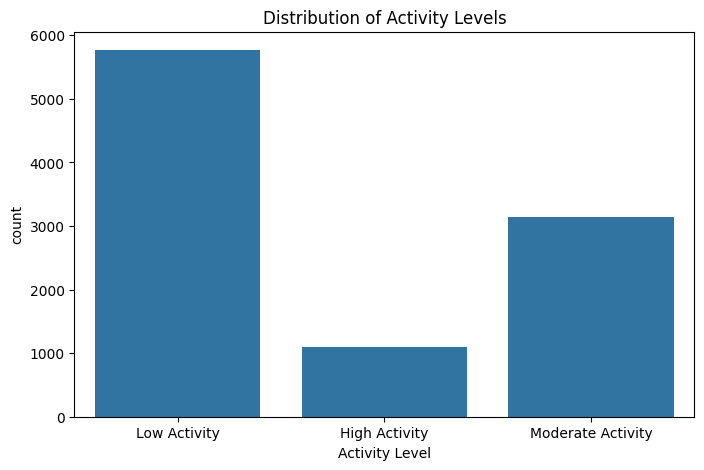

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#Visualize the distribution of activity classes
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Activity Level")

plt.title("Distribution of Activity Levels")

plt.show()

### Interpretation

The activity level distribution indicates a noticeable class imbalance within the dataset. Low Activity is the most frequently occurring class, while High Activity is the least represented.

This imbalance may influence model training by encouraging algorithms to favor the majority class during prediction. As a result, model evaluation should not rely solely on accuracy. Additional metrics such as precision, recall, and F1-score were considered to provide a more comprehensive assessment of performance across all activity levels.

The observed imbalance also justifies comparing multiple machine learning algorithms to determine which model handles minority classes most effectively.


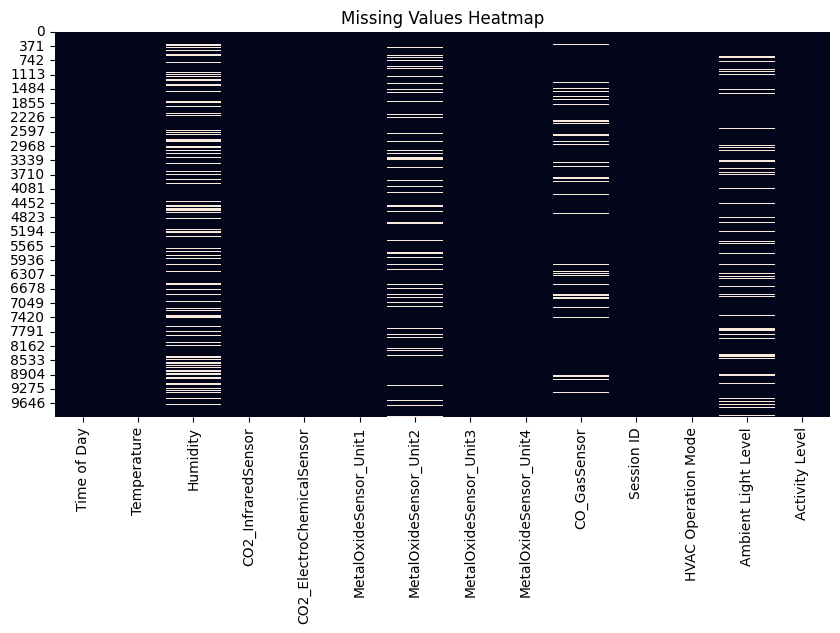

In [19]:
#Visualize the location and distribution of missing values across the dataset
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

## Outlier Detection

Boxplots were used to identify potential outliers and unrealistic sensor readings within the dataset. Detecting outliers is important because extreme values can negatively affect machine learning performance and may indicate contaminated or synthetic sensor data.

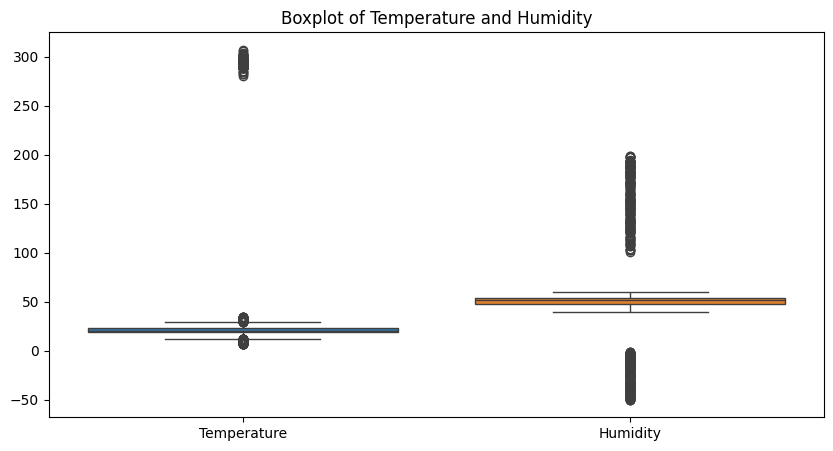

In [20]:
#Visualize temperature and humidity distributions to identify outliers
plt.figure(figsize=(10,5))

sns.boxplot(data=df[["Temperature", "Humidity"]])

plt.title("Boxplot of Temperature and Humidity")

plt.show()

In [21]:
#Display examples of unusually high temperature readings
df[df["Temperature"] > 100][["Temperature"]].head()

,Temperature
1,292.81
8,292.59
24,292.65
27,292.17
28,295.04


## Correlation Analysis

Correlation analysis was performed to examine relationships between numerical sensor features. Identifying highly correlated variables is important for understanding feature interactions, detecting redundancy, and evaluating potential multicollinearity within the dataset.

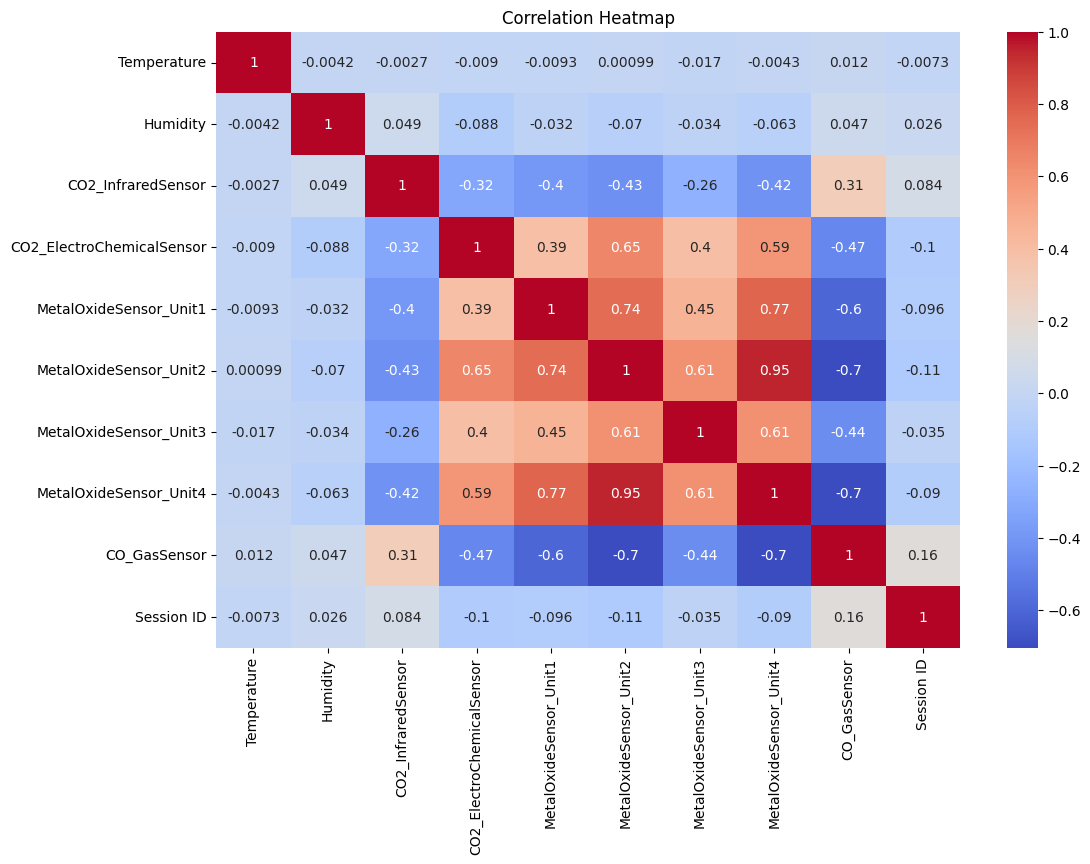

In [22]:
#Select numerical features for correlation analysis
numerical_df = df.select_dtypes(include=["float64", "int64"])

#Compute correlation matrix
corr_matrix = numerical_df.corr()

#Visualize correlations between numerical features
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The correlation heatmap was used to identify relationships between numerical sensor variables and detect potential multicollinearity within the dataset.

Most features exhibit weak to moderate correlations, indicating that the sensor measurements provide complementary information rather than being highly redundant. Several gas sensor variables show stronger relationships with one another, which is expected because they measure related environmental conditions.

The absence of widespread strong correlations suggests that retaining multiple sensor features may improve predictive performance by allowing machine learning models to capture different aspects of the indoor environment.


In [23]:
#Examine the distribution of observations across different times of day
df["Time of Day"].value_counts()

,count
Time of Day,
afternoon,2635
evening,2476
morning,2460
night,2429


In [24]:
#Examine the distribution of HVAC operating modes
df["HVAC Operation Mode"].value_counts()

,count
HVAC Operation Mode,
cooling_active,1502
maintenance_mode,1500
heating_active,1468
off,1456
eco_mode,1452
ventilation_only,1394
COOLING_ACTIVE,112
ECO_MODE,112
MAINTENANCE_MODE,106


In [25]:
#Convert HVAC labels to lowercase for consistency
df["HVAC Operation Mode"] = (
    df["HVAC Operation Mode"]
    .str.lower()
)

In [26]:
#Examine the distribution of HVAC operating modes after standardization
df["HVAC Operation Mode"].value_counts()

,count
HVAC Operation Mode,
cooling_active,1728
maintenance_mode,1703
eco_mode,1673
heating_active,1660
off,1652
ventilation_only,1584


In [27]:
#Examine the distribution of ambient lighting conditions
df["Ambient Light Level"].value_counts()

,count
Ambient Light Level,
very_bright,3387
bright,2697
moderate,1463
dim,864
very_dim,535


# 3. Data Cleaning and Preprocessing

This section performs:
- categorical cleaning,
- missing value imputation,
- feature encoding,
- train-test splitting,
- and feature scaling.

In [28]:
#Create a copy of the dataset for preprocessing
clean_df = df.copy()

In [29]:
#Replace missing numerical values using median imputation
numerical_columns = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

for col in numerical_columns:

    median_value = clean_df[col].median()

    clean_df[col].fillna(median_value, inplace=True)

/tmp/ipykernel_5338/1417219623.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(median_value, inplace=True)


In [30]:
mode_value = clean_df["Ambient Light Level"].mode()[0]

clean_df[col] = clean_df[col].fillna(median_value)

In [31]:
#Verify that all missing values have been successfully handled
clean_df.isnull().sum()

,0
Time of Day,0
Temperature,0
Humidity,0
CO2_InfraredSensor,0
CO2_ElectroChemicalSensor,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,0
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0
CO_GasSensor,0


In [32]:
#Separate input features and target variable
X = clean_df.drop("Activity Level", axis=1)

y = clean_df["Activity Level"]

In [33]:
#Identify categorical and numerical features
categorical_columns = X.select_dtypes(include=["object"]).columns

numerical_columns = X.select_dtypes(include=["float64", "int64"]).columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level'], dtype='object')

Numerical Columns:
Index(['Temperature', 'Humidity', 'CO2_InfraredSensor',
       'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1',
       'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3',
       'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID'],
      dtype='object')


In [34]:
#Remove Session ID because it is an identifier and not a predictive feature
X = X.drop("Session ID", axis=1)

In [35]:
#Apply one-hot encoding to convert categorical variables into numerical features
X = pd.get_dummies(X, drop_first=True)

In [36]:
from sklearn.model_selection import train_test_split

#Split the dataset into training and testing sets while preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Selection Justification

Three machine learning models were selected and compared for this classification task:

### Logistic Regression

Logistic Regression was selected as a baseline classification model due to its simplicity, interpretability, and computational efficiency. It provides a useful benchmark against which more complex models can be evaluated.

### Random Forest

Random Forest was selected because it can effectively model non-linear relationships, handle noisy sensor data, and provide feature importance scores. These characteristics make it well-suited for environmental monitoring datasets that may contain complex interactions between sensor readings.

### XGBoost

XGBoost was selected as an advanced ensemble learning algorithm capable of capturing complex patterns in structured tabular data. It is widely used in machine learning applications due to its strong predictive performance and robustness.


In [37]:
#Train Logistic Regression baseline classifier
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [38]:
#Standardize features for models that are sensitive to feature scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [39]:
#Train Logistic Regression using scaled features
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

# 4. Machine Learning Models

This section trains and compares multiple machine learning models for activity level classification.

The following models were implemented:

- Logistic Regression
- Random Forest
- XGBoost

The objective is to compare their performance and identify the most effective model for predicting resident activity levels using environmental sensor data.

# 5. Model Evaluation and Interpretation

This section compares model performance using:
- classification metrics,
- confusion matrices,
- and feature importance analysis.

## Evaluation Metrics

Multiple evaluation metrics were used to assess model performance:

### Accuracy

Accuracy measures the proportion of correctly classified observations out of all predictions. It provides an overall indication of model performance.

### Precision

Precision measures the proportion of positive predictions that are correct. High precision indicates fewer false positive predictions.

### Recall

Recall measures the proportion of actual observations that were correctly identified by the model. High recall indicates fewer false negatives.

### F1-Score

F1-score is the harmonic mean of precision and recall. It provides a balanced measure of model performance, especially when dealing with class imbalance.

These metrics were selected because the dataset contains multiple activity levels with unequal class distributions. Using only accuracy may not provide a complete picture of model performance, therefore precision, recall, and F1-score were also considered during model evaluation.


In [40]:
#Generate classification report for Logistic Regression
from sklearn.metrics import classification_report

y_pred = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

    High Activity       0.00      0.00      0.00       219
     Low Activity       0.65      0.85      0.74      1153
Moderate Activity       0.57      0.43      0.49       628

         accuracy                           0.63      2000
        macro avg       0.40      0.43      0.41      2000
     weighted avg       0.55      0.63      0.58      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
#Train Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [42]:
#Generate predictions using the trained Random Forest model
y_pred_rf = rf_model.predict(X_test)

#Display classification metrics for model evaluation
print(classification_report(y_test, y_pred_rf))

                   precision    recall  f1-score   support

    High Activity       0.60      0.15      0.24       219
     Low Activity       0.77      0.79      0.78      1153
Moderate Activity       0.56      0.69      0.62       628

         accuracy                           0.69      2000
        macro avg       0.65      0.54      0.55      2000
     weighted avg       0.69      0.69      0.67      2000



In [43]:
#Import XGBoost classifier and label encoder
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

#Encode target labels into numerical values
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

#Create XGBoost model with selected hyperparameters
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

#Train the XGBoost model
xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
#Import classification report for model evaluation
from sklearn.metrics import classification_report

#Generate predictions using the trained XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

#Convert encoded predictions back to original activity labels
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

#Display classification metrics for XGBoost
print(classification_report(y_test, y_pred_xgb_labels))

                   precision    recall  f1-score   support

    High Activity       0.28      0.02      0.04       219
     Low Activity       0.79      0.72      0.76      1153
Moderate Activity       0.51      0.75      0.61       628

         accuracy                           0.66      2000
        macro avg       0.53      0.50      0.47      2000
     weighted avg       0.65      0.66      0.63      2000



## Feature Importance Analysis

Feature importance analysis was conducted using the Random Forest model to identify which environmental sensor features contributed most significantly to activity level prediction. Understanding feature importance provides insight into which environmental conditions are most strongly associated with resident activity patterns.

In [45]:
#Extract feature importance scores from the trained Random Forest model
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

#Sort features by importance in descending order
feature_importances = feature_importances.sort_values(
    by="Importance",
    ascending=False
)

#Display the top 10 most important features
feature_importances.head(10)

,Feature,Importance
7,MetalOxideSensor_Unit4,0.142481
6,MetalOxideSensor_Unit3,0.130105
3,CO2_ElectroChemicalSensor,0.112465
5,MetalOxideSensor_Unit2,0.112233
4,MetalOxideSensor_Unit1,0.099601
0,Temperature,0.094758
2,CO2_InfraredSensor,0.091538
1,Humidity,0.078359
8,CO_GasSensor,0.023528
19,Ambient Light Level_very_bright,0.014049


### Interpretation

The Random Forest feature importance analysis identified several gas sensor measurements as the most influential predictors of activity level.

MetalOxideSensor_Unit4, MetalOxideSensor_Unit3, CO2_ElectroChemicalSensor, and MetalOxideSensor_Unit2 were among the highest-ranked features. This suggests that changes in indoor gas concentrations and air quality conditions may be strongly associated with resident activity patterns.

The results indicate that sensor-based environmental measurements contribute more significantly to activity prediction than some general environmental variables. This information is useful for understanding which sensors provide the greatest predictive value and may guide future sensor deployment or feature selection efforts.


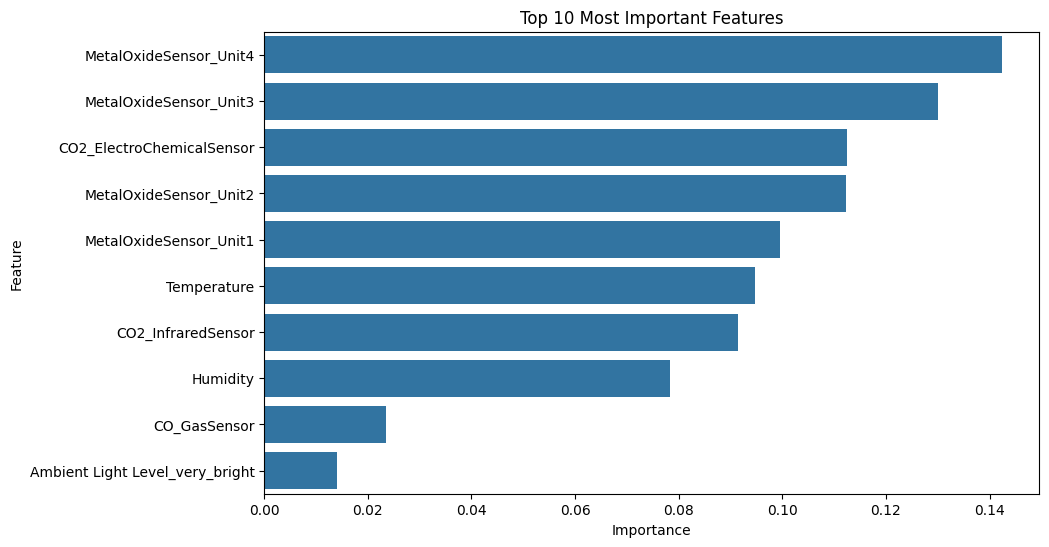

In [46]:
#Create a bar chart of the top 10 most important features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importances.head(10),
    x="Importance",
    y="Feature"
)

#Add chart title
plt.title("Top 10 Most Important Features")

#Display the visualization
plt.show()

In [47]:
#Train a Random Forest model with class balancing
rf_model_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [48]:
#Generate predictions using the balanced Random Forest model
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

#Display classification metrics for the balanced model
print(classification_report(y_test, y_pred_rf_balanced))

                   precision    recall  f1-score   support

    High Activity       0.64      0.16      0.25       219
     Low Activity       0.78      0.79      0.78      1153
Moderate Activity       0.56      0.70      0.62       628

         accuracy                           0.69      2000
        macro avg       0.66      0.55      0.55      2000
     weighted avg       0.70      0.69      0.67      2000



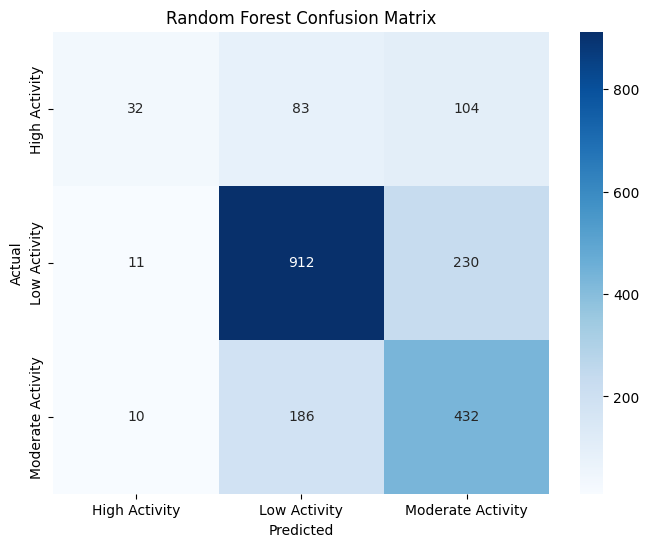

In [49]:
#Import confusion matrix for classification evaluation
from sklearn.metrics import confusion_matrix

#Generate confusion matrix using Random Forest predictions
cm = confusion_matrix(y_test, y_pred_rf)

#Create confusion matrix heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

#Add labels and title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

#Display the visualization
plt.show()

### Interpretation

The confusion matrix provides a detailed view of model predictions across activity classes.

The Random Forest model correctly classified most Low Activity observations, as indicated by the large number of values along the diagonal. However, misclassifications were more common for High Activity and Moderate Activity observations, reflecting the class imbalance identified during EDA.

Overall, the confusion matrix confirms that Random Forest performed best on the majority class while still showing some difficulty distinguishing minority activity levels.

## Model Comparison

Multiple machine learning models were evaluated and compared to determine the most effective approach for predicting resident activity levels. Model performance was assessed using classification metrics including precision, recall, F1-score, and overall accuracy.

In [50]:
#Create a table to compare the accuracy of all trained models
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        0.63,
        0.69,
        0.65,
        0.69
    ]
})

#Display model comparison results
model_results

,Model,Accuracy
0,Logistic Regression,0.63
1,Random Forest,0.69
2,XGBoost,0.65
3,Balanced Random Forest,0.69


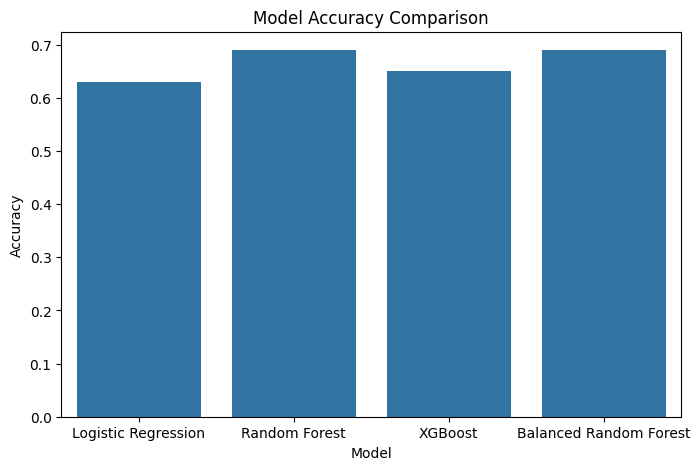

In [51]:
#Visualize model accuracy comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

### Interpretation

Random Forest and Balanced Random Forest achieved the highest accuracy of 69%, outperforming Logistic Regression and XGBoost.

Although the balanced version attempted to address class imbalance, its overall performance remained similar to the standard Random Forest model. Therefore, Random Forest was selected as the final model due to its strong predictive performance and simpler configuration.

# Gas Monitoring Activity Classification

## Project Objective

The objective of this project is to develop machine learning models capable of predicting the activity level of elderly residents using environmental sensor data collected from smart home monitoring systems.

The dataset contains information related to indoor air quality, gas sensor measurements, environmental conditions, HVAC operation modes, and ambient lighting conditions. Since the problem statement indicates that the dataset may contain contaminated or synthetic data, particular attention is given to data quality assessment, missing value handling, outlier detection, and feature preprocessing.

This project includes:

* Data loading from a SQLite database
* Exploratory Data Analysis (EDA)
* Data cleaning and preprocessing
* Feature engineering and encoding
* Machine learning model development
* Hyperparameter tuning
* Model evaluation and comparison
* Feature importance analysis

The machine learning models evaluated in this project are:

1. Logistic Regression
2. Random Forest
3. XGBoost

The final objective is to identify the most effective model for activity level prediction while also determining which environmental features contribute most significantly to the prediction process.


In [57]:
#Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

#Define parameter combinations to evaluate
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

#Perform grid search using cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

#Train and evaluate all parameter combinations
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted')

In [58]:
#Display the best hyperparameter combination
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [59]:
#Retrieve the best Random Forest model identified by GridSearchCV
best_rf_model = grid_search.best_estimator_

#Generate predictions using the tuned Random Forest model
y_pred_best_rf = best_rf_model.predict(X_test)

#Display classification metrics for the tuned model
print(classification_report(y_test, y_pred_best_rf))

                   precision    recall  f1-score   support

    High Activity       0.67      0.11      0.19       219
     Low Activity       0.79      0.78      0.79      1153
Moderate Activity       0.56      0.73      0.63       628

         accuracy                           0.69      2000
        macro avg       0.67      0.54      0.54      2000
     weighted avg       0.70      0.69      0.67      2000



### Hyperparameter Tuning Interpretation

GridSearchCV was applied to optimize Random Forest hyperparameters using weighted F1-score and 3-fold cross-validation. The tuned model achieved similar performance to the original Random Forest model, suggesting that model performance is more strongly influenced by the dataset characteristics than by hyperparameter selection.

# 6. Conclusion

This project explored environmental sensor data collected from elderly residents’ homes to predict activity levels using machine learning techniques.

Key findings from the analysis include:

- The dataset contained missing values, inconsistent categorical labels, and unrealistic sensor readings, confirming the presence of contaminated or synthetic data.
- Significant class imbalance was observed, with Low Activity representing the majority class.
- Random Forest achieved the strongest overall performance compared to Logistic Regression, XGBoost, and the Balanced Random Forest model.
- Hyperparameter tuning using GridSearchCV produced a tuned Random Forest model, although performance remained similar to the original Random Forest model.
- Feature importance analysis revealed that Metal Oxide Sensors and electrochemical CO2 sensors contributed most significantly to activity prediction.

Overall, the project demonstrated that environmental sensor data can provide meaningful insight into resident activity patterns while also highlighting the challenges associated with noisy and imbalanced healthcare monitoring datasets. Among the evaluated models, Random Forest achieved the best overall performance, demonstrating its ability to capture complex relationships between environmental sensor measurements and resident activity levels. Its strong performance, combined with feature importance analysis, makes it the most suitable model for this dataset.